11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8810 - loss: 0.4283
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9666 - loss: 0.1140
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0778
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9842 - loss: 0.0545
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9875 - loss: 0.0425
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0871
Test Accuracy: 0.9786999821662903
Enter the image path (example: digit.png): digit 2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Digit = 2


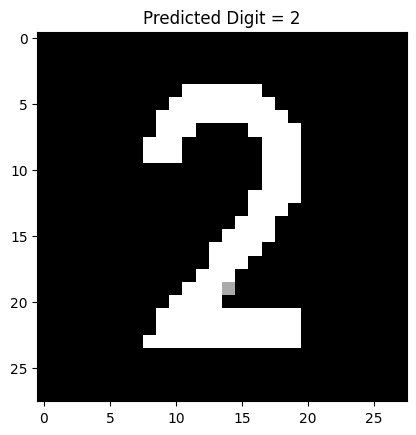

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import cv2
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0


model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.fit(x_train, y_train, epochs=5)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


img_path = input("Enter the image path (example: digit.png): ")


img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


img = cv2.resize(img, (28, 28))

img = img / 255.0


img = np.array(img).reshape(1, 28, 28)


prediction = model.predict(img)
predicted_digit = prediction.argmax()

print("Predicted Digit =", predicted_digit)


plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title("Predicted Digit = " + str(predicted_digit))
plt.show()